In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision as tv
from torchvision.datasets import MovingMNIST
import matplotlib.pyplot as plt
from tqdm import tqdm

LSTM in PyTorch. 
- ResNet-18 as a frozen feature extraction backbone for image embeddings

Ref: https://colab.research.google.com/drive/1mC5CWwekbZ2NrYv6Zfpuv55z8DuOZXVP?usp=sharing#scrollTo=LUZiROnzjFD_

100%|██████████| 819M/819M [00:21<00:00, 38.4MB/s] 


Dataset size: 10000
Data point: torch.Size([10, 1, 64, 64])


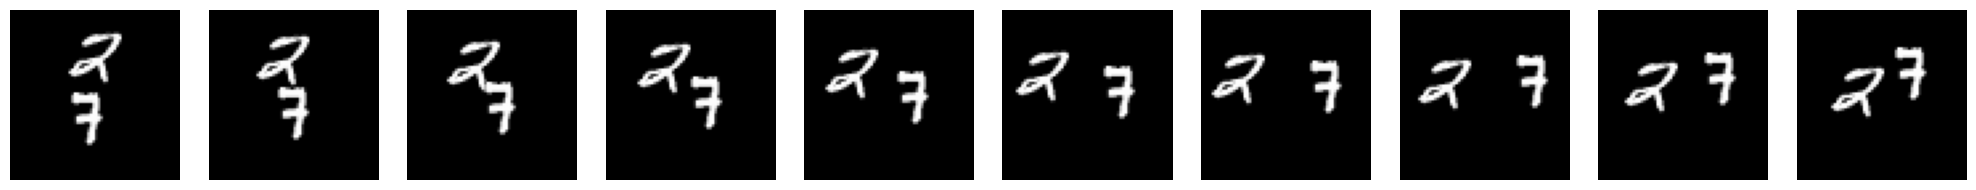

In [11]:
train_dataset = MovingMNIST(root=".", split="train", download=True)
print(f"Dataset size: {len(train_dataset)}")

item = train_dataset[0]
print(f"Data point: {item.shape}")
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(item.shape[0]):
    img = item[i, 0, :, :]
    axes[i].imshow(img, cmap='gray')
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

batch = next(iter(train_dataloader))
print(batch.shape) # (N,L,C,H,W) -> L = Sequence Length (Frames)

# We want to predict the next frame, so leave out index 9  -> [:, :9]
# ResNet-18 expects 3-channel input, so triple dimension C -> repeates=3, dim=2
#   - repeat_interleave places repetitions consecutively
# Pytorch RNNs expect (L,N,C,H,W)                          -> .permute(1,0,2,3,4) 
input = torch.repeat_interleave(batch[:, :9], repeats=3, dim=2).permute(1,0,2,3,4)
print(f"Input: {input.shape}")

# To match expected predictions, offset target frames by 1 -> [:, 1:]
# No need to repeat channels, as these are ground truths
target = batch[:, 1:].permute(1,0,2,3,4)
print(f"Target: {target.shape}")

torch.Size([8, 10, 1, 64, 64])
Input: torch.Size([9, 8, 3, 64, 64])
Target: torch.Size([9, 8, 1, 64, 64])


In [6]:
# Encoder Backbone
resnet_net = tv.models.resnet18(weights="DEFAULT")
modules = list(resnet_net.children())[:-1] # drop classifier head
backbone = torch.nn.Sequential(*modules) # feature extractor

test_input_enc = torch.rand(8, 3, 64, 64)
print(backbone(test_input_enc).shape)

torch.Size([8, 512, 1, 1])


In [7]:
# Decoder Module
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(256), nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

decoder = Decoder()
test_input_dec = torch.rand(8, 512, 1, 1)
print(decoder(test_input_dec).shape)

torch.Size([8, 1, 64, 64])


In [8]:
# LSTM
model = torch.nn.LSTM(input_size=512, hidden_size=512) # Expects (L,N,Embedding_Dim)

test_input_LSTM = torch.rand(9, 8, 512)
output, (hidden_state, cell_state) = model(test_input_LSTM)
print("LSTM Output:", output.shape)

LSTM Output: torch.Size([9, 8, 512])


In [9]:
for i, batch in enumerate(tqdm(train_dataloader)):
	# Prepare input/target
	batch_size = batch.shape[0]
	input = torch.repeat_interleave(batch[:,:9], repeats=3, dim=2).permute(1,0,2,3,4)
	target = batch[:,1:].permute(1,0,2,3,4)

	# Encode
	# Keep ResNet as a frozen pretrained backbone
	with torch.no_grad():
		L, N, C, H, W = input.shape				     			    # (9, 8, 3, 64, 64)
		# Flatten (L,N) -> batch of (72) for ResNet
		backbone_input = input.reshape(-1,C,H,W).float()            # (72, 3, 64, 64)
		# Unflatten (72) -> (L,N) 
		embedded_input = backbone(backbone_input).reshape(L, N, -1) # (9, 8, 512)

	# Forward Pass
	predictions, (h, c) = model(embedded_input) 				    # (9, 8, 512)

	# Decode
	decoder_input = predictions.reshape(L*N, -1, 1, 1)			    # (72, 512, 1, 1)
	decoded_image = decoder(decoder_input).reshape(L, N, 1, 64, 64) # (9, 8, 1, 64, 64)

	# Sanity check
	if i == 0:
		print("Prediction:", decoded_image.shape)
		print("Ground Truth:", target.shape)

  0%|          | 4/1250 [00:00<01:21, 15.36it/s]

Prediction: torch.Size([9, 8, 1, 64, 64])
Ground Truth: torch.Size([9, 8, 1, 64, 64])


100%|██████████| 1250/1250 [01:11<00:00, 17.47it/s]


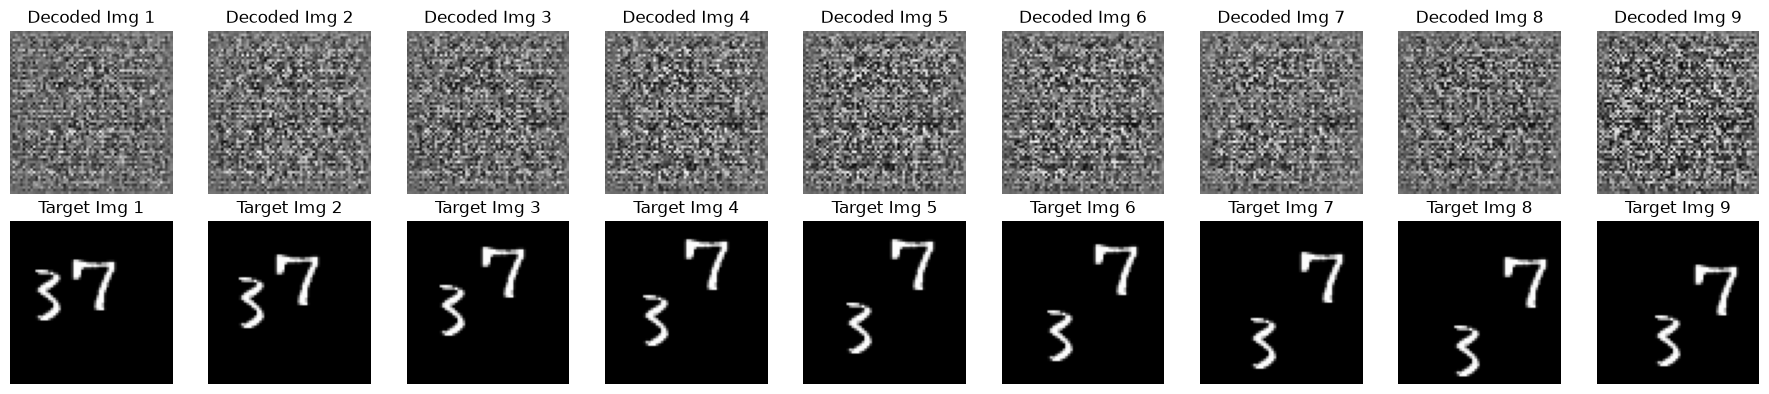

In [10]:
# Visualize outputs
# Select the 0th element along dim=1 for both tensors
decoded_img_0 = decoded_image[:, 0, :, :].detach().numpy()
target_0 = target[:, 0, :, :].detach().numpy()

# Visualize the two sequences of images in a grid
fig, axes = plt.subplots(nrows=2, ncols=9, figsize=(18, 4))

for i in range(9):
    # Display decoded_img_0 images in the first row
    axes[0, i].imshow(decoded_img_0[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Decoded Img {i+1}')

    # Display target_0 images in the second row
    axes[1, i].imshow(target_0[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Target Img {i+1}')

plt.tight_layout()
plt.show()